# Computer Vision Lab — Task 02
### Effect of Image Filtering on Skin-Lesion Classification

**Builds on Lab 1 (Task 01).** Lab 1's Table 1 ranked 8 transfer-learning backbones on the
5-class ISIC skin-lesion subset; the three highest-accuracy backbones were:

| Rank | Model | Accuracy (Lab 1) |
|---|---|---|
| 1 | **ResNet50** | 70.00% |
| 2 | **VGG19** | 65.00% |
| 3 | **ResNet101** | 63.75% (tiebreak over VGG16, also 63.75%, by higher F1 and AUC) |

This notebook uses those three as **Best Model 1/2/3** and repeats classification under a
**baseline (no filter)** condition plus **five spatial-domain filters** (Average, Gaussian,
Median, Sharpening, Sobel), keeping dataset split, preprocessing, training settings, and
evaluation procedure identical across all 18 (3 model x 6 condition) runs, as the lab requires.

**Dataset note:** this continues the same 5-class ISIC subset (`actinic keratosis`,
`basal cell carcinoma`, `melanoma`, `nevus`, `pigmented benign keratosis`) and the same
stratified 90/10 train/validation split from Lab 1, used here as the instructor-approved
subset in place of a separate HAM10000 download -- the two datasets are both drawn from the
ISIC archive and cover the same lesion classification task. If your instructor wants the
original HAM10000 CSV/image release specifically, swap the data-loading cell below for that
source; everything downstream (filters, training, evaluation) is dataset-agnostic.

> Run this on Kaggle Notebooks or Google Colab with a GPU. 18 full training runs is
> substantial GPU time -- budget accordingly, and feel free to trim `MODELS` or `FILTERS`
> while debugging before running the full grid for your submitted results.


## 1. Setup

In [1]:
!pip install -q kagglehub opencv-python-headless scikit-learn


In [2]:
import os, time, copy, random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, balanced_accuracy_score,
                              confusion_matrix, classification_report)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


## 2. Dataset preparation

Same download, 5-class selection, and stratified 90/10 split as Lab 1.

In [3]:
import kagglehub

path = kagglehub.dataset_download("nodoubttome/skin-cancer9-classesisic")
BASE_DIR = os.path.join(path, "Skin cancer ISIC The International Skin Imaging Collaboration")
TRAIN_DIR = os.path.join(BASE_DIR, "Train")
TEST_DIR  = os.path.join(BASE_DIR, "Test")
assert os.path.isdir(TRAIN_DIR) and os.path.isdir(TEST_DIR), "Adjust TRAIN_DIR/TEST_DIR to match the printed structure"

ALL_CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))

SELECTED_CLASSES = [
    "actinic keratosis",
    "basal cell carcinoma",
    "melanoma",
    "nevus",
    "pigmented benign keratosis",
]
missing = [c for c in SELECTED_CLASSES if c not in ALL_CLASS_NAMES]
assert not missing, f"Missing class folders: {missing}"

CLASS_TO_IDX = {c: i for i, c in enumerate(SELECTED_CLASSES)}
NUM_CLASSES = len(SELECTED_CLASSES)
IMG_SIZE = 224
BATCH_SIZE = 32

print(f"Using {NUM_CLASSES} classes:", SELECTED_CLASSES)


Using Colab cache for faster access to the 'skin-cancer9-classesisic' dataset.
Using 5 classes: ['actinic keratosis', 'basal cell carcinoma', 'melanoma', 'nevus', 'pigmented benign keratosis']


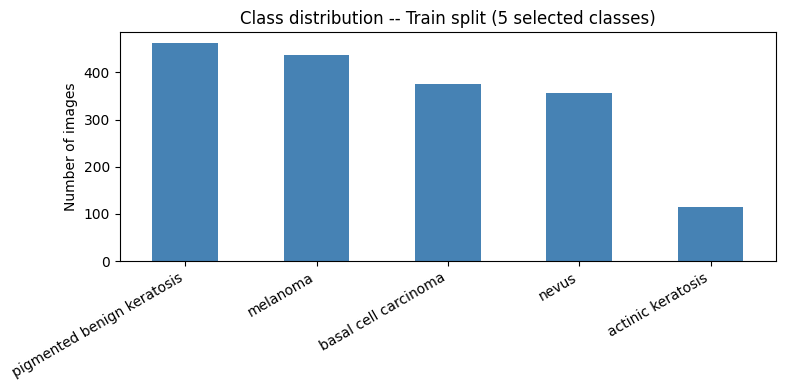

pigmented benign keratosis    462
melanoma                      438
basal cell carcinoma          376
nevus                         357
actinic keratosis             114
Name: count, dtype: int64


In [4]:
def filter_imagefolder_to_classes(dataset, class_to_idx):
    old_idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}
    new_samples = [
        (p, class_to_idx[old_idx_to_class[l]])
        for p, l in dataset.samples if old_idx_to_class[l] in class_to_idx
    ]
    dataset.samples = new_samples
    dataset.imgs = new_samples
    dataset.targets = [s[1] for s in new_samples]
    dataset.classes = list(class_to_idx.keys())
    dataset.class_to_idx = class_to_idx
    return dataset


# Class distribution (Additional Analysis requirement)
raw_train = filter_imagefolder_to_classes(datasets.ImageFolder(TRAIN_DIR), CLASS_TO_IDX)
counts = pd.Series([SELECTED_CLASSES[t] for t in raw_train.targets]).value_counts()
plt.figure(figsize=(8, 4))
counts.plot(kind="bar", color="steelblue")
plt.title("Class distribution -- Train split (5 selected classes)")
plt.ylabel("Number of images")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
print(counts)


## 3. Image filtering

Five spatial-domain filters, each implemented with OpenCV and wrapped as a
torchvision-compatible transform applied to the **resized, still-uint8 RGB image**, before
any augmentation or normalization -- so filtering is a fixed preprocessing step, identical for
every image regardless of train/val/test split.

In [5]:
def apply_filter(img_np, filter_name):
    # img_np: HxWx3 uint8 RGB array. Returns a filtered HxWx3 uint8 RGB array.
    if filter_name == "No Filter":
        return img_np
    if filter_name == "Average":
        return cv2.blur(img_np, (5, 5))
    if filter_name == "Gaussian":
        return cv2.GaussianBlur(img_np, (5, 5), sigmaX=0)
    if filter_name == "Median":
        return cv2.medianBlur(img_np, 5)
    if filter_name == "Sharpening":
        kernel = np.array([[0, -1, 0],
                            [-1, 5, -1],
                            [0, -1, 0]], dtype=np.float32)
        return cv2.filter2D(img_np, -1, kernel)
    if filter_name == "Sobel":
        gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        mag = cv2.magnitude(gx, gy)
        mag = np.clip(mag / (mag.max() + 1e-8) * 255, 0, 255).astype(np.uint8)
        return cv2.cvtColor(mag, cv2.COLOR_GRAY2RGB)  # replicate to 3 channels for the CNN
    raise ValueError(filter_name)


class FilterTransform:
    # PIL Image -> filtered PIL Image.
    def __init__(self, filter_name):
        self.filter_name = filter_name

    def __call__(self, pil_img):
        arr = np.array(pil_img.convert("RGB"))
        filtered = apply_filter(arr, self.filter_name)
        from PIL import Image
        return Image.fromarray(filtered)


FILTERS = ["No Filter", "Average", "Gaussian", "Median", "Sharpening", "Sobel"]


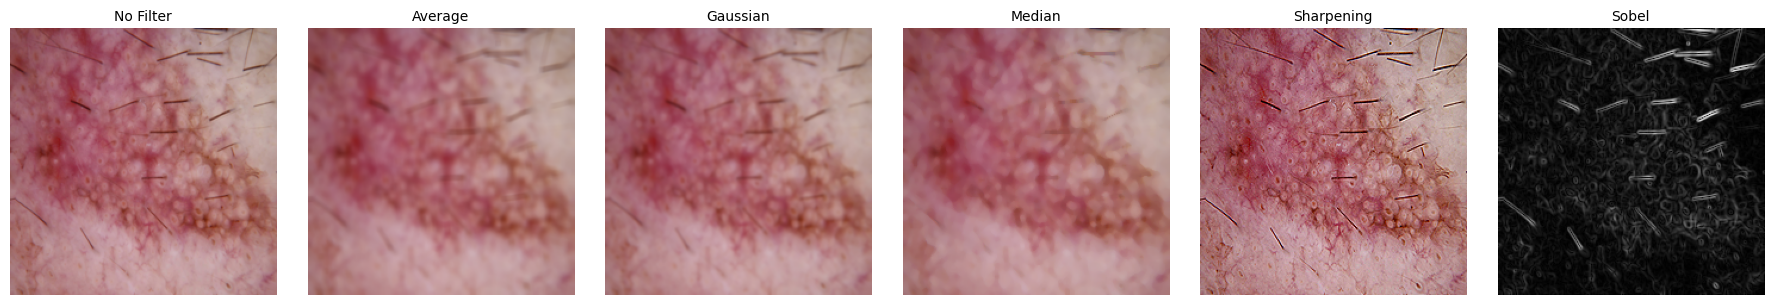

In [6]:
# Visual sanity check: one sample image under every filter (Additional Analysis requirement)
sample_path, _ = raw_train.samples[0]
from PIL import Image
sample_img = Image.open(sample_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))

fig, axes = plt.subplots(1, len(FILTERS), figsize=(3 * len(FILTERS), 3))
for ax, fname in zip(axes, FILTERS):
    filtered = FilterTransform(fname)(sample_img)
    ax.imshow(filtered)
    ax.set_title(fname, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 4. Dataloaders per filter condition

Same stratified 90/10 split (by index) reused across every filter -- only the filter inserted into the pipeline changes, so all other conditions (split, batch size, augmentation) stay identical for a fair comparison.

In [7]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def make_transforms(filter_name, train: bool):
    ops = [transforms.Resize((IMG_SIZE, IMG_SIZE)), FilterTransform(filter_name)]
    if train:
        ops += [
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.RandomAffine(degrees=0, translate=(0.2, 0.2), shear=10, scale=(0.8, 1.2)),
        ]
    ops += [transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]
    return transforms.Compose(ops)


# Fixed stratified split, computed once and reused for every filter condition
_base_ds = filter_imagefolder_to_classes(datasets.ImageFolder(TRAIN_DIR), CLASS_TO_IDX)
_targets = _base_ds.targets
_indices = np.arange(len(_targets))
TRAIN_IDX, VAL_IDX = train_test_split(_indices, test_size=0.10, stratify=_targets, random_state=SEED)


def build_dataloaders(filter_name):
    train_full = filter_imagefolder_to_classes(
        datasets.ImageFolder(TRAIN_DIR, transform=make_transforms(filter_name, train=True)),
        CLASS_TO_IDX)
    val_full = filter_imagefolder_to_classes(
        datasets.ImageFolder(TRAIN_DIR, transform=make_transforms(filter_name, train=False)),
        CLASS_TO_IDX)
    test_ds = filter_imagefolder_to_classes(
        datasets.ImageFolder(TEST_DIR, transform=make_transforms(filter_name, train=False)),
        CLASS_TO_IDX)

    train_ds = Subset(train_full, TRAIN_IDX)
    val_ds = Subset(val_full, VAL_IDX)

    return (
        DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2),
        DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2),
        DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2),
    )


## 5. Model loading

Only the three Lab-1 winners: ResNet50, VGG19, ResNet101.

In [8]:
def build_model(name: str, num_classes: int):
    name = name.lower()
    if name == "resnet50":
        m = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
        head_attr = ("fc", None)
    elif name == "vgg19":
        m = models.vgg19(weights=models.VGG19_Weights.DEFAULT)
        m.classifier[6] = nn.Linear(m.classifier[6].in_features, num_classes)
        head_attr = ("classifier", 6)
    elif name == "resnet101":
        m = models.resnet101(weights=models.ResNet101_Weights.DEFAULT)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
        head_attr = ("fc", None)
    else:
        raise ValueError(name)
    return m, head_attr


def set_backbone_trainable(model, trainable, head_attr):
    for p in model.parameters():
        p.requires_grad = trainable
    attr, idx = head_attr
    head = getattr(model, attr)
    if idx is not None:
        head = head[idx]
    for p in head.parameters():
        p.requires_grad = True


MODELS = ["resnet50", "vgg19", "resnet101"]


## 6. Training (baseline + every filter, same settings throughout)

Same two-phase fine-tuning and early-stopping policy as Lab 1, kept identical across every model/filter combination so filtering is the only variable that changes.

In [9]:
class EarlyStopper:
    def __init__(self, patience=3, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float("inf")
        self.counter = 0
        self.best_state = None

    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_state = copy.deepcopy(model.state_dict())
            return False
        self.counter += 1
        return self.counter >= self.patience

    def restore(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(is_train):
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            if is_train:
                optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            if is_train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            n += x.size(0)
    return total_loss / n, correct / n


def train_model(model_name, train_loader, val_loader, num_classes,
                 feat_epochs=3, ft_epochs=10, lr_head=1e-3, lr_ft=1e-4, ft_patience=3):
    model, head_attr = build_model(model_name, num_classes)
    model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    set_backbone_trainable(model, False, head_attr)
    opt = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr_head)
    for ep in range(feat_epochs):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, opt)
        val_loss, val_acc = run_epoch(model, val_loader, criterion)
        history["train_loss"].append(tr_loss); history["val_loss"].append(val_loss)
        history["train_acc"].append(tr_acc); history["val_acc"].append(val_acc)

    set_backbone_trainable(model, True, head_attr)
    opt = optim.Adam(model.parameters(), lr=lr_ft)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(opt, factor=(0.1) ** 0.5, patience=2)
    stopper = EarlyStopper(patience=ft_patience)
    for ep in range(ft_epochs):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, opt)
        val_loss, val_acc = run_epoch(model, val_loader, criterion)
        history["train_loss"].append(tr_loss); history["val_loss"].append(val_loss)
        history["train_acc"].append(tr_acc); history["val_acc"].append(val_acc)
        scheduler.step(val_loss)
        if stopper.step(val_loss, model):
            break
    stopper.restore(model)
    return model, history


## 7. Evaluation

Precision/Recall/F1-score use **weighted** averaging (reflects overall performance given class imbalance); **Macro-F1** and **Balanced Accuracy** use unweighted per-class averaging (surfaces minority-class performance) -- reported as separate columns so both views are visible side by side, per the lab's Additional Analysis requirement.

In [10]:
@torch.no_grad()
def evaluate_model(model, loader, class_names):
    model.eval()
    all_probs, all_preds, all_labels = [], [], []
    for x, y in loader:
        x = x.to(DEVICE)
        out = model(x)
        probs = torch.softmax(out, dim=1).cpu().numpy()
        all_probs.append(probs); all_preds.append(probs.argmax(1)); all_labels.append(y.numpy())
    probs = np.concatenate(all_probs)
    preds = np.concatenate(all_preds)
    labels = np.concatenate(all_labels)

    acc = accuracy_score(labels, preds)
    prec_w = precision_score(labels, preds, average="weighted", zero_division=0)
    rec_w = recall_score(labels, preds, average="weighted", zero_division=0)
    f1_w = f1_score(labels, preds, average="weighted", zero_division=0)
    macro_f1 = f1_score(labels, preds, average="macro", zero_division=0)
    bal_acc = balanced_accuracy_score(labels, preds)
    try:
        auc = roc_auc_score(labels, probs, multi_class="ovr", average="macro")
    except ValueError:
        auc = float("nan")

    cm = confusion_matrix(labels, preds)
    report = classification_report(labels, preds, target_names=class_names,
                                    output_dict=True, zero_division=0)

    metrics = dict(Accuracy=acc * 100, Precision=prec_w * 100, Recall=rec_w * 100,
                   F1_Score=f1_w * 100, Macro_F1=macro_f1 * 100,
                   Balanced_Accuracy=bal_acc * 100, AUC=auc * 100)
    return metrics, cm, report


## 8. Main experiment loop -- 3 models x 6 conditions = 18 runs

In [11]:
results_rows = []
histories = {}     # (model, filter) -> history dict
confusions = {}     # (model, filter) -> confusion matrix
reports = {}        # (model, filter) -> per-class classification report

for model_name in MODELS:
    for filter_name in FILTERS:
        print(f"\n===== {model_name} | {filter_name} =====")
        train_loader, val_loader, test_loader = build_dataloaders(filter_name)
        model, history = train_model(model_name, train_loader, val_loader, NUM_CLASSES)
        metrics, cm, report = evaluate_model(model, test_loader, SELECTED_CLASSES)

        label = "Best Model 1" if model_name == MODELS[0] else \
                "Best Model 2" if model_name == MODELS[1] else "Best Model 3"
        results_rows.append({"Model": f"{label} ({model_name})", "Filter": filter_name, **metrics})

        histories[(model_name, filter_name)] = history
        confusions[(model_name, filter_name)] = cm
        reports[(model_name, filter_name)] = report

        del model
        torch.cuda.empty_cache()

results_df = pd.DataFrame(results_rows).round(2)
results_df



===== resnet50 | No Filter =====
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 188MB/s]



===== resnet50 | Average =====

===== resnet50 | Gaussian =====

===== resnet50 | Median =====

===== resnet50 | Sharpening =====

===== resnet50 | Sobel =====

===== vgg19 | No Filter =====
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:07<00:00, 76.8MB/s]



===== vgg19 | Average =====

===== vgg19 | Gaussian =====

===== vgg19 | Median =====

===== vgg19 | Sharpening =====

===== vgg19 | Sobel =====

===== resnet101 | No Filter =====
Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /root/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth


100%|██████████| 171M/171M [00:01<00:00, 171MB/s]



===== resnet101 | Average =====

===== resnet101 | Gaussian =====

===== resnet101 | Median =====

===== resnet101 | Sharpening =====

===== resnet101 | Sobel =====


,Model,Filter,Accuracy,Precision,Recall,F1_Score,Macro_F1,Balanced_Accuracy,AUC
0,Best Model 1 (resnet50),No Filter,70.00,73.30,70.00,68.50,68.50,70.00,90.72
1,Best Model 1 (resnet50),Average,61.25,66.51,61.25,59.40,59.40,61.25,87.34
2,Best Model 1 (resnet50),Gaussian,63.75,67.47,63.75,58.16,58.16,63.75,90.66
3,Best Model 1 (resnet50),Median,61.25,75.79,61.25,56.75,56.75,61.25,91.13
4,Best Model 1 (resnet50),Sharpening,57.50,48.83,57.50,50.89,50.89,57.50,89.45
5,Best Model 1 (resnet50),Sobel,45.00,41.07,45.00,42.09,42.09,45.00,81.66
6,Best Model 2 (vgg19),No Filter,66.25,72.84,66.25,63.47,63.47,66.25,93.05
7,Best Model 2 (vgg19),Average,62.50,62.00,62.50,56.94,56.94,62.50,92.38
8,Best Model 2 (vgg19),Gaussian,62.50,65.42,62.50,57.18,57.18,62.50,92.36
9,Best Model 2 (vgg19),Median,66.25,69.16,66.25,62.13,62.13,66.25,90.90


## 9. Visualization

Training/validation curves for every run, plus confusion matrices for the baseline and each filtered condition.

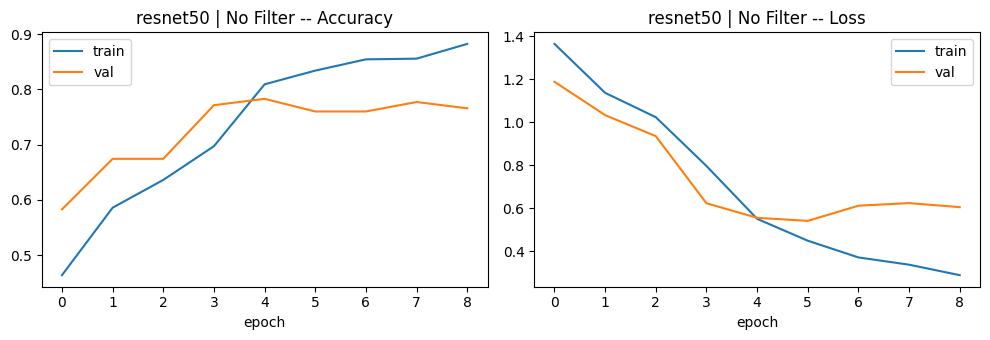

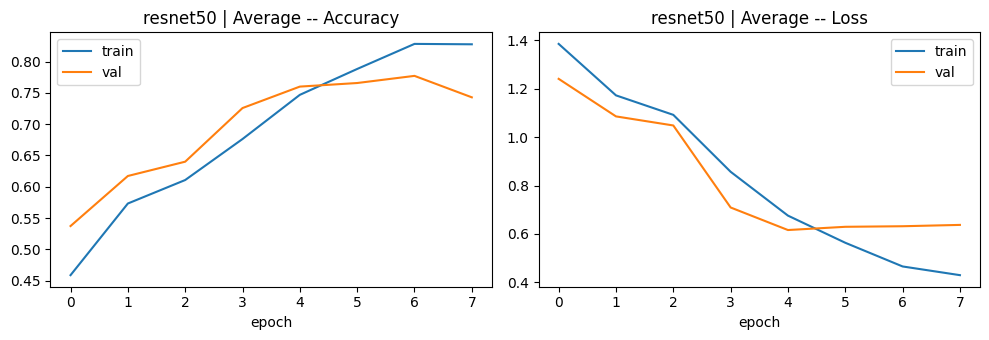

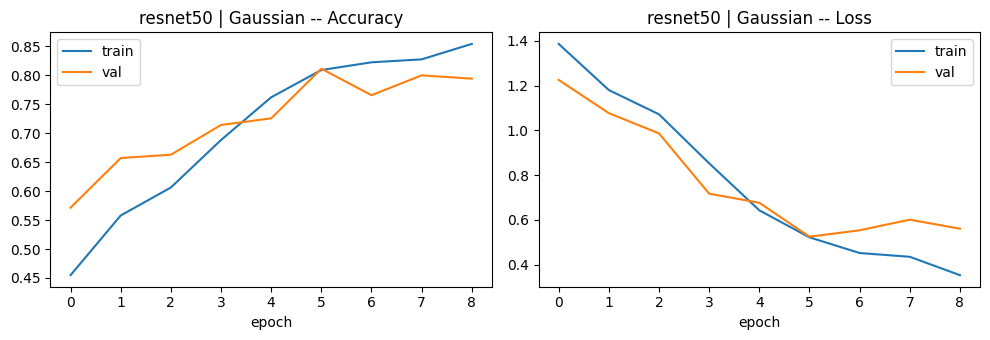

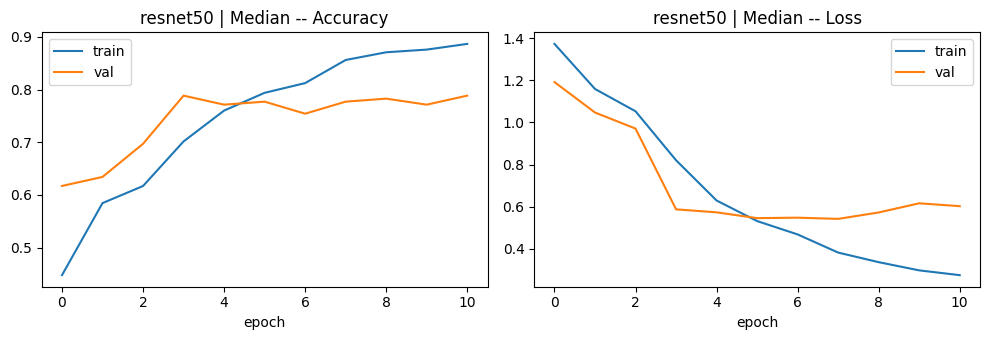

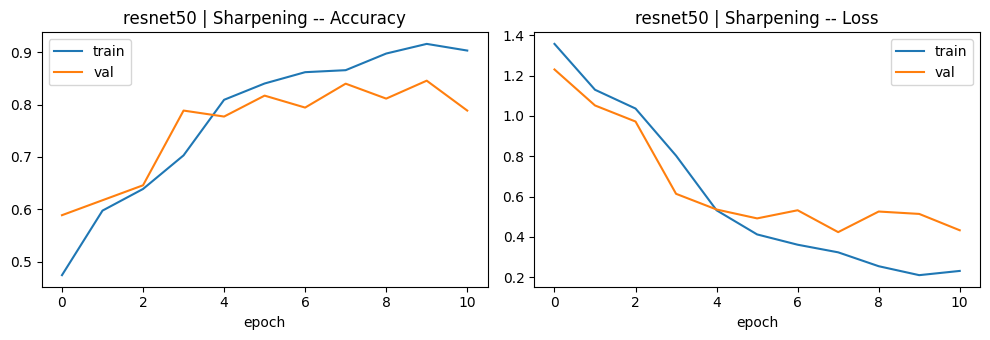

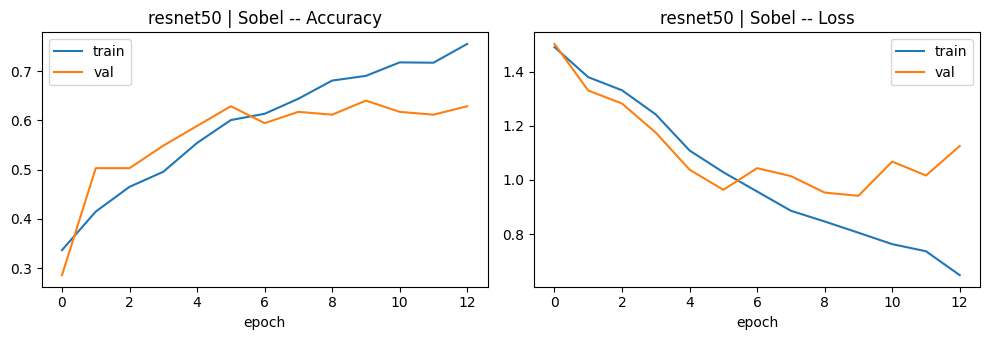

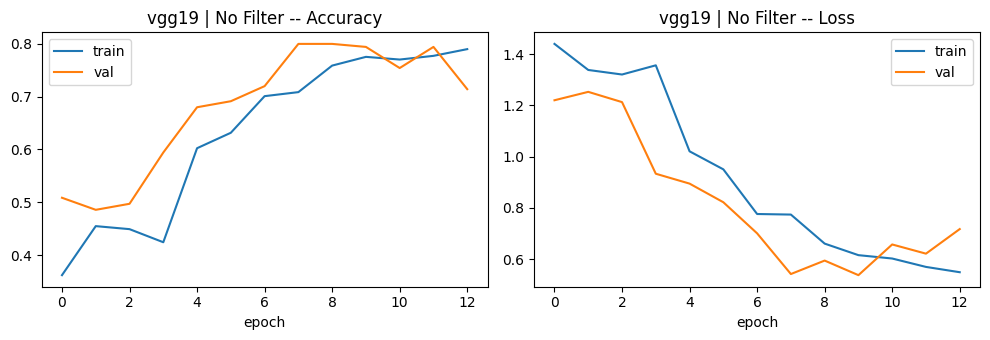

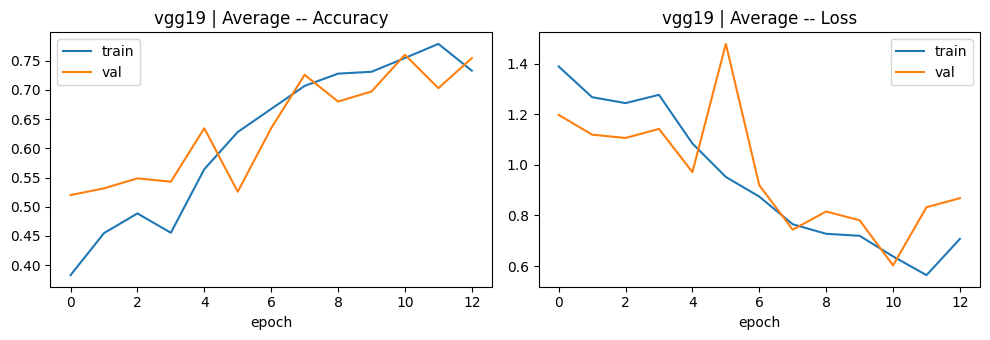

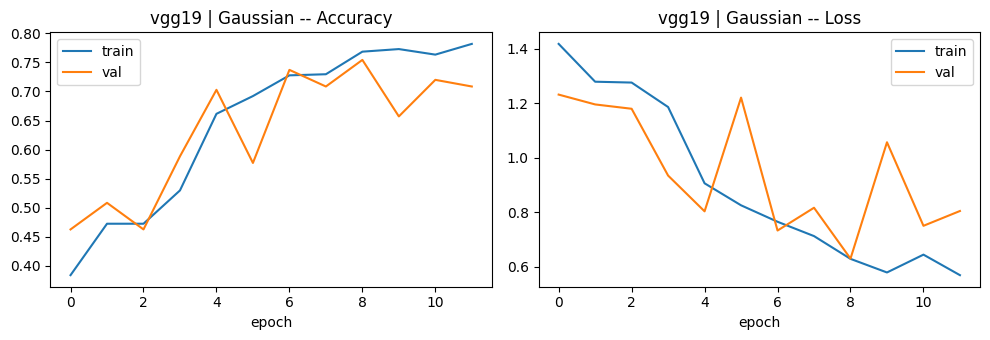

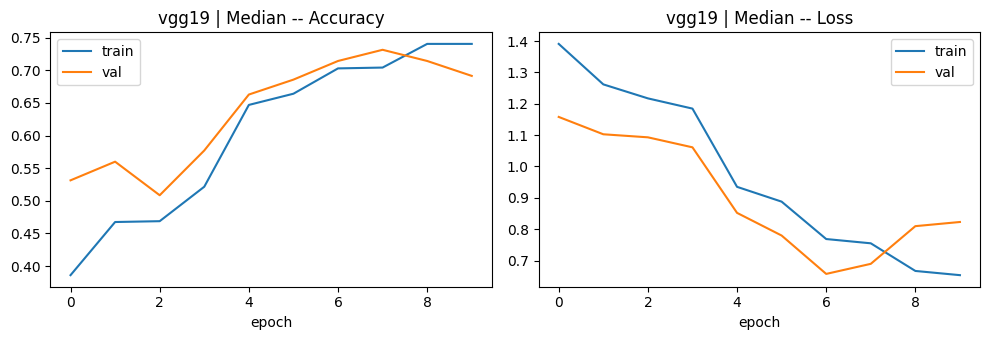

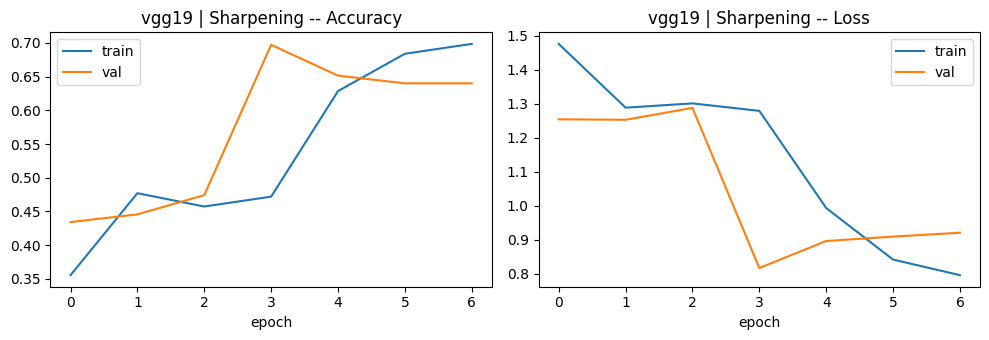

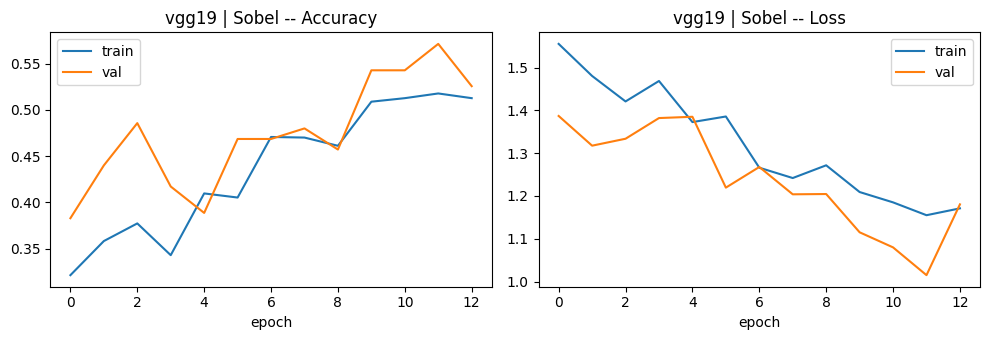

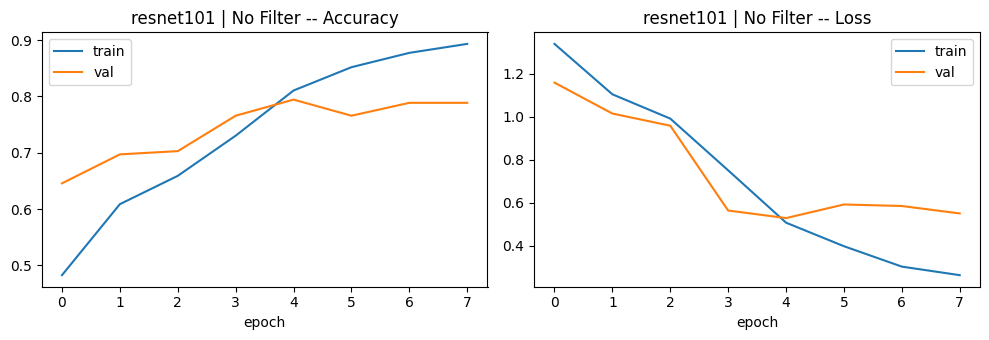

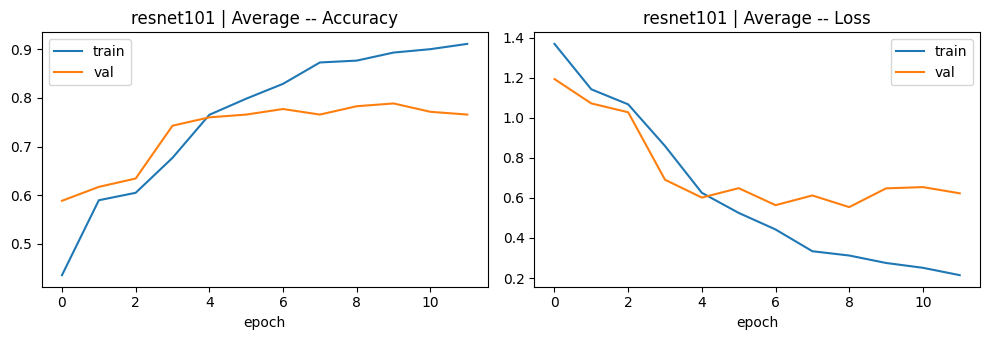

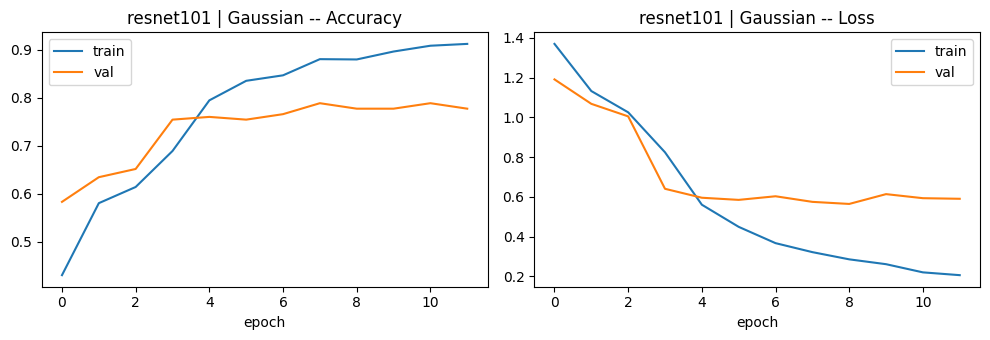

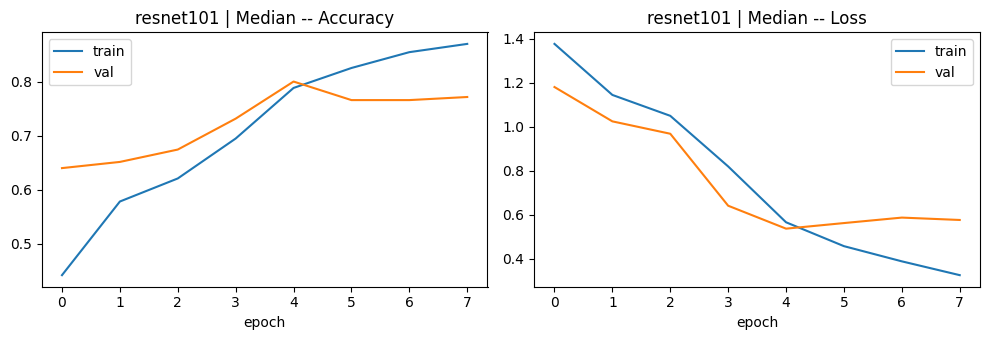

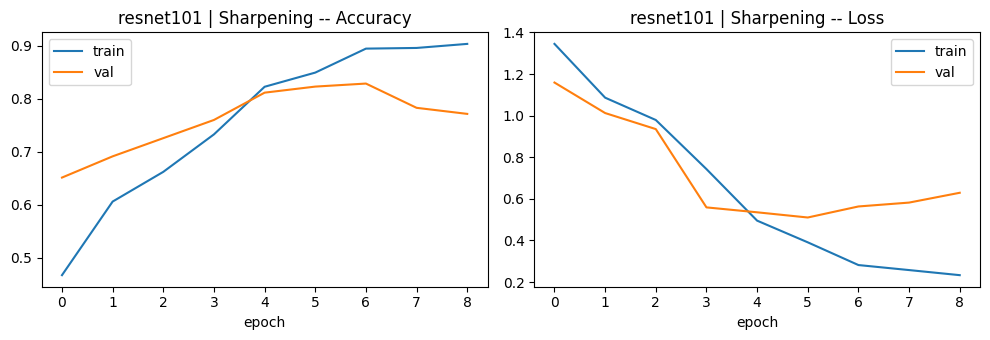

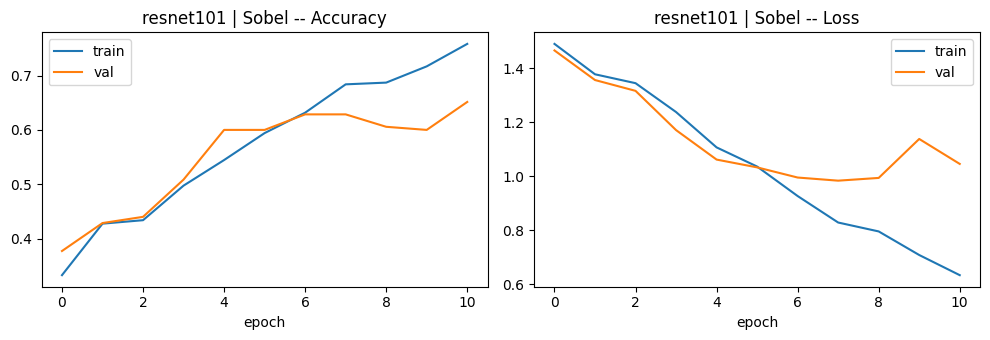

In [12]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    axes[0].plot(history["train_acc"], label="train")
    axes[0].plot(history["val_acc"], label="val")
    axes[0].set_title(f"{title} -- Accuracy"); axes[0].set_xlabel("epoch"); axes[0].legend()
    axes[1].plot(history["train_loss"], label="train")
    axes[1].plot(history["val_loss"], label="val")
    axes[1].set_title(f"{title} -- Loss"); axes[1].set_xlabel("epoch"); axes[1].legend()
    plt.tight_layout()
    plt.show()


for (model_name, filter_name), history in histories.items():
    plot_history(history, f"{model_name} | {filter_name}")


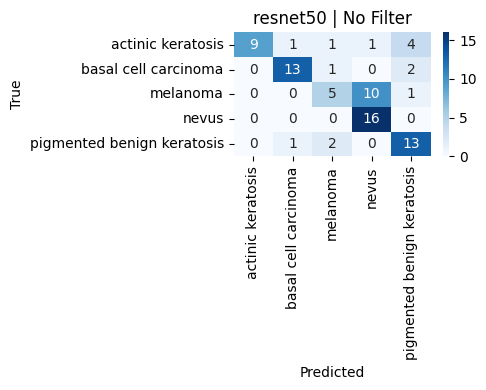

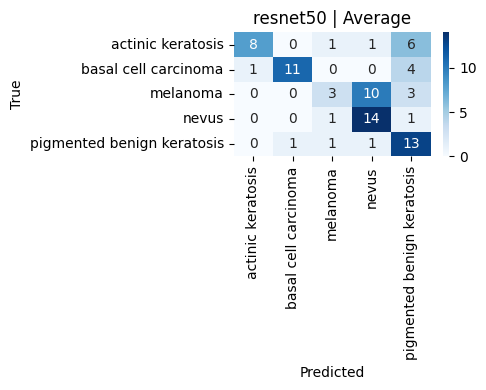

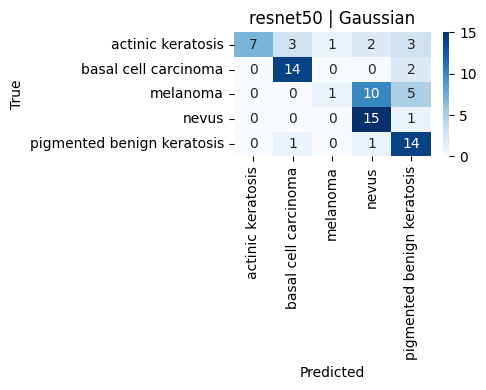

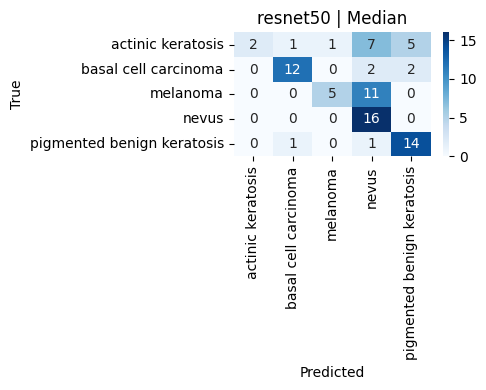

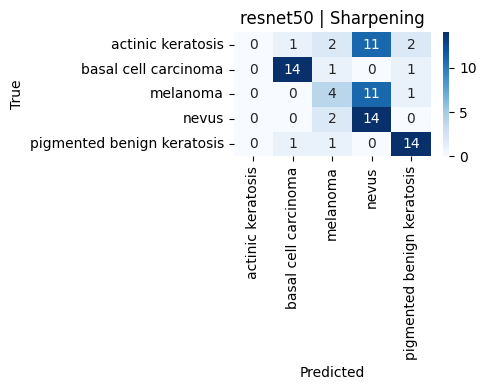

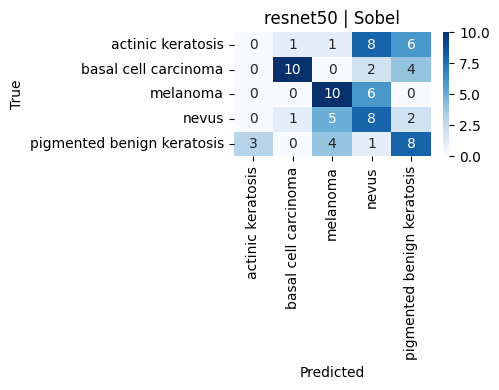

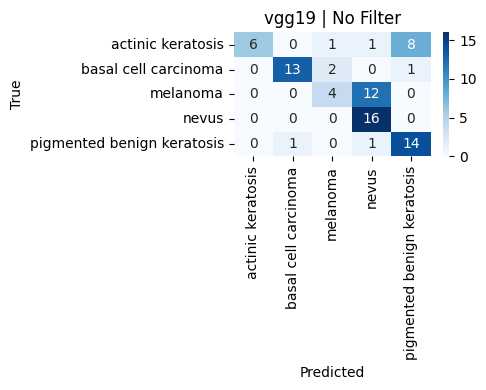

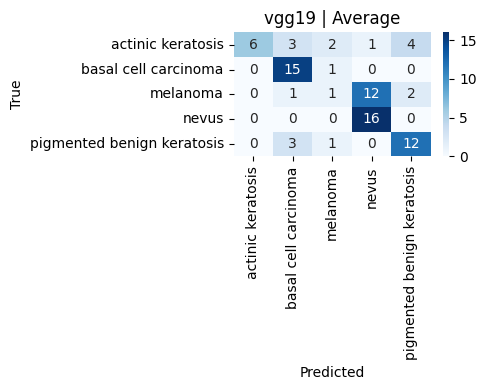

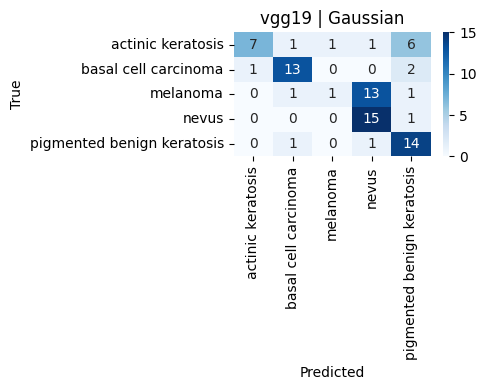

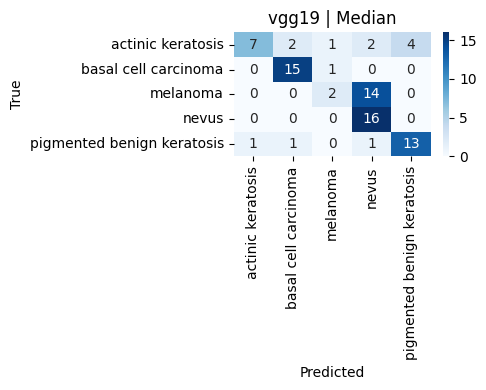

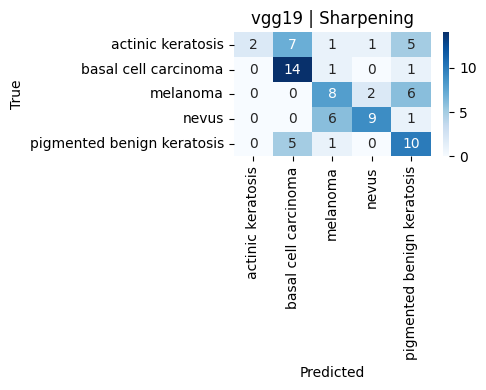

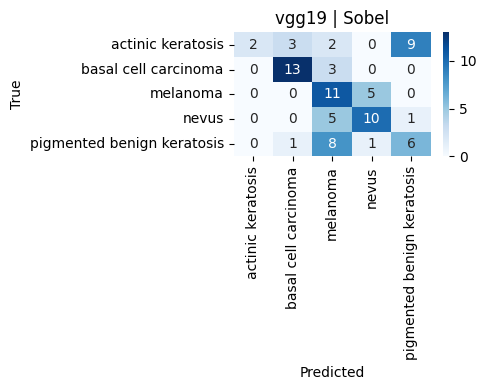

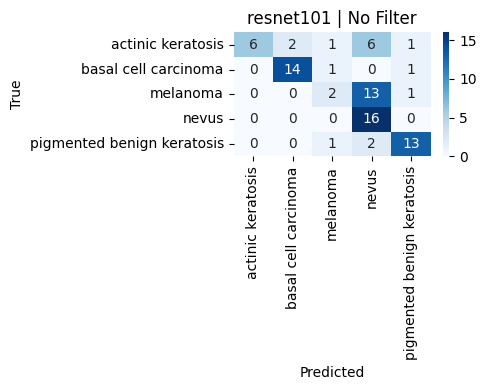

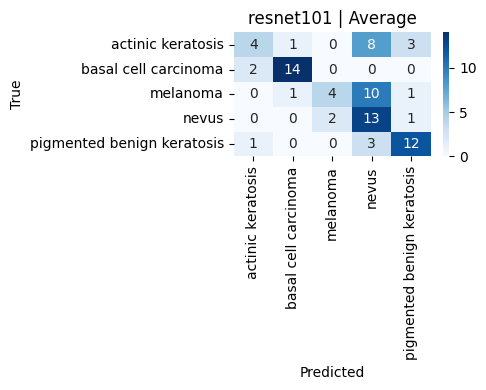

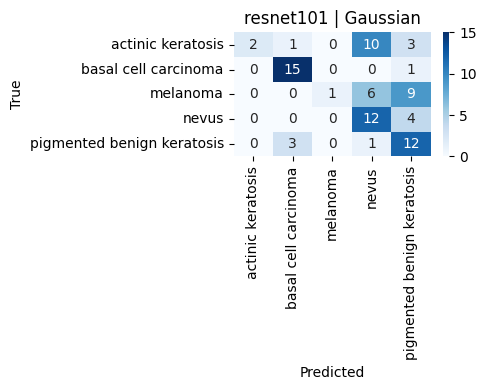

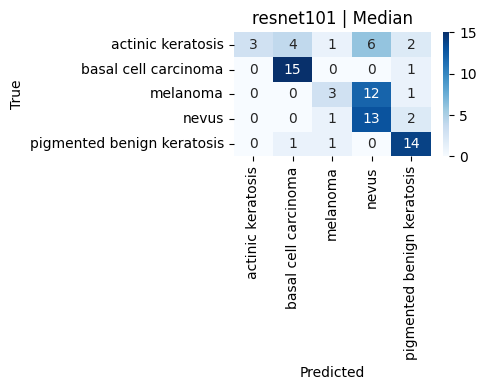

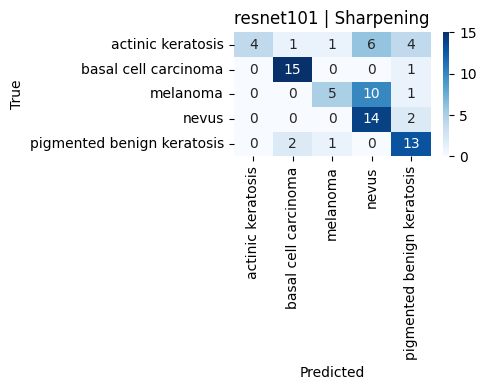

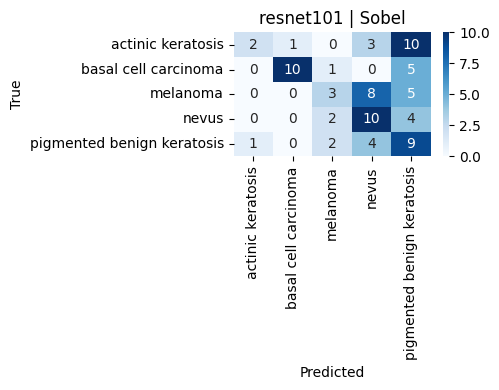

In [13]:
def plot_confusion(cm, class_names, title):
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title); plt.ylabel("True"); plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()


for (model_name, filter_name), cm in confusions.items():
    plot_confusion(cm, SELECTED_CLASSES, f"{model_name} | {filter_name}")


In [14]:
# Per-class precision/recall/F1 for every run (Additional Analysis requirement)
per_class_rows = []
for (model_name, filter_name), report in reports.items():
    for cls in SELECTED_CLASSES:
        r = report[cls]
        per_class_rows.append({
            "Model": model_name, "Filter": filter_name, "Class": cls,
            "Precision": round(r["precision"] * 100, 2),
            "Recall": round(r["recall"] * 100, 2),
            "F1_Score": round(r["f1-score"] * 100, 2),
        })
per_class_df = pd.DataFrame(per_class_rows)
per_class_df


,Model,Filter,Class,Precision,Recall,F1_Score
0,resnet50,No Filter,actinic keratosis,100.00,56.25,72.00
1,resnet50,No Filter,basal cell carcinoma,86.67,81.25,83.87
2,resnet50,No Filter,melanoma,55.56,31.25,40.00
3,resnet50,No Filter,nevus,59.26,100.00,74.42
4,resnet50,No Filter,pigmented benign keratosis,65.00,81.25,72.22
...,...,...,...,...,...,...
85,resnet101,Sobel,actinic keratosis,66.67,12.50,21.05
86,resnet101,Sobel,basal cell carcinoma,90.91,62.50,74.07
87,resnet101,Sobel,melanoma,37.50,18.75,25.00
88,resnet101,Sobel,nevus,40.00,62.50,48.78


## 10. Comparative analysis

Accuracy of each model across filter conditions, and the largest deviation from each model's own No-Filter baseline -- directly answers *which filter produces the greatest change* and *whether the effect is consistent across models*.

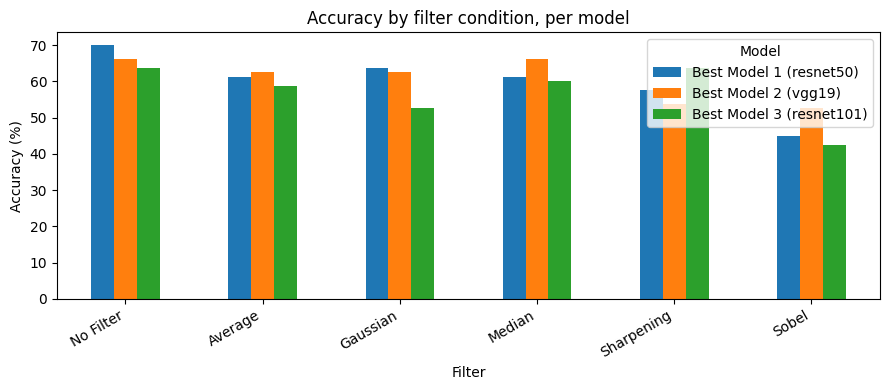

Model,Best Model 1 (resnet50),Best Model 2 (vgg19),Best Model 3 (resnet101)
Filter,,,
No Filter,70.00,66.25,63.75
Average,61.25,62.50,58.75
Gaussian,63.75,62.50,52.50
Median,61.25,66.25,60.00
Sharpening,57.50,53.75,63.75
Sobel,45.00,52.50,42.50


In [15]:
pivot = results_df.pivot(index="Filter", columns="Model", values="Accuracy")
pivot = pivot.reindex(FILTERS)
pivot.plot(kind="bar", figsize=(9, 4))
plt.title("Accuracy by filter condition, per model")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
pivot


In [16]:
baseline = pivot.loc["No Filter"]
delta = pivot.subtract(baseline, axis=1).drop(index="No Filter")
print("Change in accuracy vs. each model's own No-Filter baseline (percentage points):")
delta.round(2)


Change in accuracy vs. each model's own No-Filter baseline (percentage points):


Model,Best Model 1 (resnet50),Best Model 2 (vgg19),Best Model 3 (resnet101)
Filter,,,
Average,-8.75,-3.75,-5.00
Gaussian,-6.25,-3.75,-11.25
Median,-8.75,0.00,-3.75
Sharpening,-12.50,-12.50,0.00
Sobel,-25.00,-13.75,-21.25


In [17]:
os.makedirs("results", exist_ok=True)
results_df.to_csv("results/lab02_filter_comparison.csv", index=False)
per_class_df.to_csv("results/lab02_per_class_metrics.csv", index=False)
print("Saved results/lab02_filter_comparison.csv and results/lab02_per_class_metrics.csv")
results_df


Saved results/lab02_filter_comparison.csv and results/lab02_per_class_metrics.csv


,Model,Filter,Accuracy,Precision,Recall,F1_Score,Macro_F1,Balanced_Accuracy,AUC
0,Best Model 1 (resnet50),No Filter,70.00,73.30,70.00,68.50,68.50,70.00,90.72
1,Best Model 1 (resnet50),Average,61.25,66.51,61.25,59.40,59.40,61.25,87.34
2,Best Model 1 (resnet50),Gaussian,63.75,67.47,63.75,58.16,58.16,63.75,90.66
3,Best Model 1 (resnet50),Median,61.25,75.79,61.25,56.75,56.75,61.25,91.13
4,Best Model 1 (resnet50),Sharpening,57.50,48.83,57.50,50.89,50.89,57.50,89.45
5,Best Model 1 (resnet50),Sobel,45.00,41.07,45.00,42.09,42.09,45.00,81.66
6,Best Model 2 (vgg19),No Filter,66.25,72.84,66.25,63.47,63.47,66.25,93.05
7,Best Model 2 (vgg19),Average,62.50,62.00,62.50,56.94,56.94,62.50,92.38
8,Best Model 2 (vgg19),Gaussian,62.50,65.42,62.50,57.18,57.18,62.50,92.36
9,Best Model 2 (vgg19),Median,66.25,69.16,66.25,62.13,62.13,66.25,90.90
